In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from datetime import datetime, timedelta
import yfinance as yf

# Q1- Stock selection & market data

In [2]:
ticker = "AAPL"
end_date = datetime(2026, 2, 17)
start_date = end_date - timedelta(days=365)
data = yf.download(ticker, start=start_date, end=end_date)

prices = data["Close"].reset_index()
prices.columns = ["Date", "Close"]
prices["Date"] = pd.to_datetime(prices["Date"]).dt.normalize()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [3]:
# Risk-free rate from FRED (10-Year Treasury)
# Source: https://fred.stlouisfed.org/series/DGS10
r_df = pd.read_csv("/Users/eduardo/Desktop/Python_Coding/Quant Finance/RiskManagement/Project/DGS10.csv")
r_df = r_df.rename(columns={"observation_date": "Date"})
r_df["Date"] = pd.to_datetime(r_df["Date"]).dt.normalize()
r_df["DGS10"] = pd.to_numeric(r_df["DGS10"], errors="coerce")

In [4]:
df = pd.merge(prices, r_df, on="Date", how="inner").dropna()

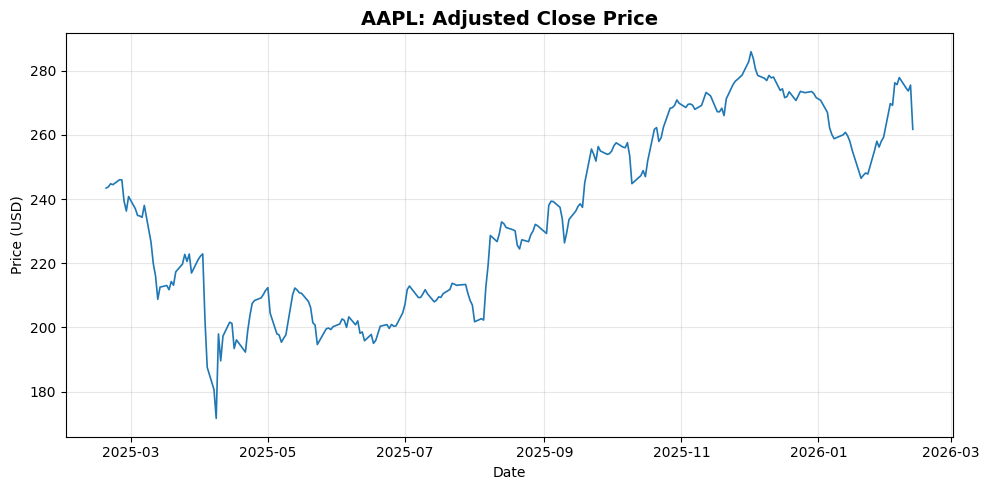

In [5]:
# Plot stock prices
plt.figure(figsize=(10, 5))
plt.plot(df["Date"], df["Close"], color="#1f77b4", linewidth=1.2)
plt.title(f"{ticker}: Adjusted Close Price", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Q2 - Parameter estimation

In [6]:
# 2a) Risk-free rate -- last available 10Y Treasury yield
T = 1.0

# 2b) Projection period = 1 year (matches rate horizon)
r = df["DGS10"].iloc[-1] / 100

# 2c) Annualized volatility (lookback = T = 1 year)
daily_log_returns = np.log(df["Close"]).diff().dropna()
mu_daily = daily_log_returns.mean()
mu_annual = mu_daily * 252

sigma_daily = daily_log_returns.std(ddof=1)
sigma_annual = sigma_daily * np.sqrt(252)

In [7]:
# Current price & strike
S = df["Close"].iloc[-1]
K = df["Close"].mean()

In [8]:
print("Q2 -- Parameters")
print("=" * 50)
print(f"  Risk-free rate (r):      {r:.4f} ({r*100:.2f}%)")
print(f"  Source:                  FRED 10Y Treasury (DGS10)")
print(f"  Projection period (T):   {T} year")
print(f"  Current price (S):       ${S:.2f}")
print(f"  Strike price (K = mean): ${K:.2f}")
print(f"  Daily mean return (mu):  {mu_daily:.6f}")
print(f"  Annualized return (mu):  {mu_annual:.4f} ({mu_annual*100:.2f}%)")
print(f"  Daily volatility:        {sigma_daily:.6f}")
print(f"  Annualized vol (sigma):  {sigma_annual:.4f} ({sigma_annual*100:.2f}%)")

Q2 -- Parameters
  Risk-free rate (r):      0.0409 (4.09%)
  Source:                  FRED 10Y Treasury (DGS10)
  Projection period (T):   1.0 year
  Current price (S):       $261.73
  Strike price (K = mean): $234.73
  Daily mean return (mu):  0.000295
  Annualized return (mu):  0.0743 (7.43%)
  Daily volatility:        0.020184
  Annualized vol (sigma):  0.3204 (32.04%)


# Q3 - Black-Scholes

## (a) — Black–Scholes Model

The **Black–Scholes–Merton (1973)** model prices European options using a closed-form formula.

### Option Pricing Formulas

Call option price:

$$
C = S\,N(d_1) - K e^{-rT} N(d_2)
$$

Put option price:

$$
P = K e^{-rT} N(-d_2) - S N(-d_1)
$$

### Definitions of \( $d_1$ \) and \( $d_2$ \)

$$
d_1 = \frac{\ln(S/K) + \left(r + \frac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}
$$

$$
d_2 = d_1 - \sigma\sqrt{T}
$$

### Model Assumptions

1. The stock price follows **Geometric Brownian Motion** with constant drift and volatility.  
2. **No dividends** are paid during the life of the option.  
3. **No transaction costs or taxes**.  
4. The **risk-free interest rate \(r\)** is constant and known.  
5. The **volatility \( $\sigma$ \)** of the underlying asset is constant and known.  
6. The option is **European-style**, meaning it can only be exercised at expiration.  
7. **Short selling is allowed** without restrictions.  
8. **Continuous trading** in the market is possible.  
9. Asset returns are **log-normally distributed**.

In [9]:
# Q3b - Defining Call option pricing (Black-Scholes)
N = norm.cdf

def BS_CALL(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * N(d1) - K * np.exp(-r * T) * N(d2)

call_price = BS_CALL(S, K, T, r, sigma_annual)

d1 = (np.log(S / K) + (r + sigma_annual**2 / 2) * T) / (sigma_annual * np.sqrt(T))
d2 = d1 - sigma_annual * np.sqrt(T)

In [10]:
print("Q3b -- Call Option (Black-Scholes)")
print("=" * 50)
print(f"  d1 = {d1:.6f}")
print(f"  d2 = {d2:.6f}")
print(f"  N(d1) = {N(d1):.6f}")
print(f"  N(d2) = {N(d2):.6f}")
print(f"  Call price = ${call_price:.2f}")

Q3b -- Call Option (Black-Scholes)
  d1 = 0.627641
  d2 = 0.307235
  N(d1) = 0.734880
  N(d2) = 0.620668
  Call price = $52.49


## (c) — Put Option via Put–Call Parity

Using **Put–Call Parity**, the relationship between European call and put prices is:

$$
C - P = S - K e^{-rT}
$$

Rearranging to solve for the **put price**:

$$
P = C - S + K e^{-rT}
$$

In [11]:
# Q3c - Put option via Put-Call Parity + Payoff & PnL

# Put-Call Parity: C - P = S - K*e^(-rT)  =>  P = C - S + K*e^(-rT)
put_price = call_price - S + K * np.exp(-r * T)

# Verification with direct BS formula
put_direct = K * np.exp(-r * T) * N(-d2) - S * N(-d1)

In [12]:
print("Q3c -- Put Option (Put-Call Parity)")
print("=" * 50)
print(f"  P = C - S + K * e^(-rT)")
print(f"  P = {call_price:.2f} - {S:.2f} + {K:.2f} * e^(-{r:.4f}*{T})")
print(f"  Put price (parity)  = ${put_price:.2f}")
print(f"  Put price (direct)  = ${put_direct:.2f}")
print(f"  Parity verified:      {np.isclose(put_price, put_direct)}")

Q3c -- Put Option (Put-Call Parity)
  P = C - S + K * e^(-rT)
  P = 52.49 - 261.73 + 234.73 * e^(-0.0409*1.0)
  Put price (parity)  = $16.08
  Put price (direct)  = $16.08
  Parity verified:      True


In [13]:
# Payoff and PnL of the put option
put_breakeven = K - put_price
ST_range = np.linspace(K * 0.5, K * 1.5, 500)
put_payoff = np.maximum(K - ST_range, 0)
put_pnl = put_payoff - put_price

print(f"  Put Payoff & PnL:")
print(f"  Payoff = max(K - S_T, 0)")
print(f"  PnL    = max(K - S_T, 0) - P")
print(f"  Max profit (S_T -> 0): ${K - put_price:.2f}")
print(f"  Max loss (S_T > K):    -${put_price:.2f}")
print(f"  Break-even:            ${put_breakeven:.2f}")

  Put Payoff & PnL:
  Payoff = max(K - S_T, 0)
  PnL    = max(K - S_T, 0) - P
  Max profit (S_T -> 0): $218.65
  Max loss (S_T > K):    -$16.08
  Break-even:            $218.65


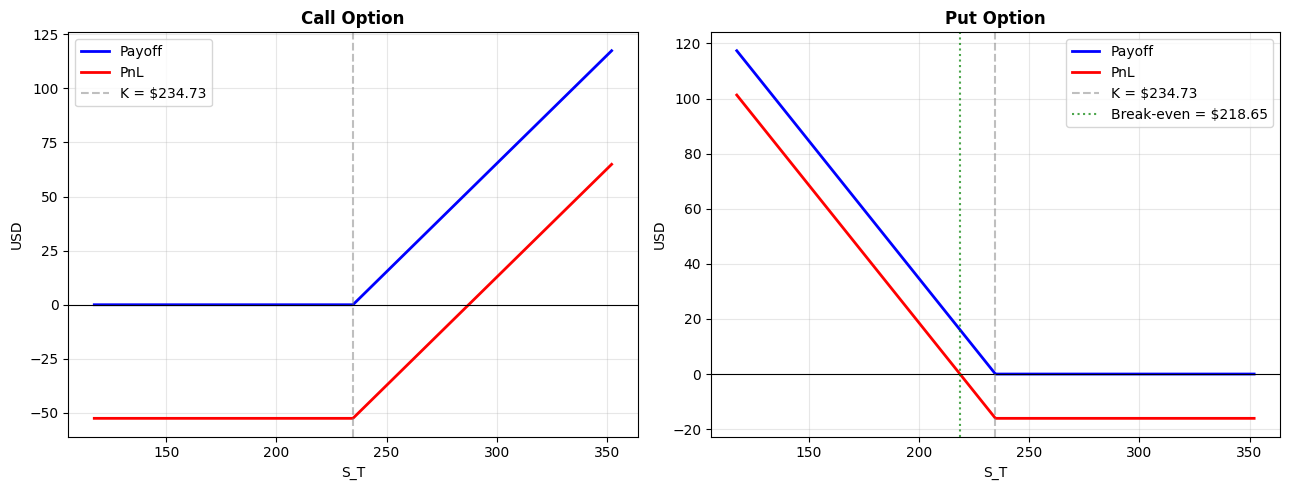

In [14]:
# Plot payoff and PnL
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Call
call_payoff = np.maximum(ST_range - K, 0)
call_pnl = call_payoff - call_price
axes[0].plot(ST_range, call_payoff, "b-", linewidth=2, label="Payoff")
axes[0].plot(ST_range, call_pnl, "r-", linewidth=2, label="PnL")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].axvline(K, color="gray", linestyle="--", alpha=0.5, label=f"K = ${K:.2f}")
axes[0].set_title("Call Option", fontweight="bold")
axes[0].set_xlabel("S_T")
axes[0].set_ylabel("USD")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Put
axes[1].plot(ST_range, put_payoff, "b-", linewidth=2, label="Payoff")
axes[1].plot(ST_range, put_pnl, "r-", linewidth=2, label="PnL")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axvline(K, color="gray", linestyle="--", alpha=0.5, label=f"K = ${K:.2f}")
axes[1].axvline(put_breakeven, color="green", linestyle=":", alpha=0.7,
                label=f"Break-even = ${put_breakeven:.2f}")
axes[1].set_title("Put Option", fontweight="bold")
axes[1].set_xlabel("S_T")
axes[1].set_ylabel("USD")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Q4 — Greeks (sensitivities)
In option pricing, the **Greeks** are partial derivatives of the option value with respect to model inputs.
They quantify how the option price reacts to changes in the underlying factors such as price, time, volatility, and rates.

The key Greeks of Black-Scholes for European Options are:

- **Delta** expresses the irectional exposure to the underlying price
:  
  $$
  \Delta = \frac{\partial C}{\partial S}
  $$  

- **Gamma** captures the curvature of the option value (how Delta changes when $S$ moves):  
  $$
  \Gamma = \frac{\partial^2 C}{\partial S^2}
  $$  

- **Theta** reflects time decay:  
  $$
  \Theta = \frac{\partial C}{\partial t}
  $$  
  

- **Vega** expresses sensitivity to volatility:  
  $$
  \nu = \frac{\partial C}{\partial \sigma}
  $$  
  .

- **Rho**  reflects the sensitivity to the risk-free interest rate:  
  $$
  \rho = \frac{\partial C}{\partial r}
  $$  

Below, we compute the Greeks for the call option priced in **Q3b** (using the same $S, K, T, r, \sigma$).


In [15]:
# Q4 — Greeks for the Q3b call option
def bs_d1_d2(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

def bs_call_price(S, K, T, r, sigma):
    d1, d2 = bs_d1_d2(S, K, T, r, sigma)
    return S * N(d1) - K * np.exp(-r * T) * N(d2)

def bs_greeks_call(S, K, T, r, sigma, *, call_price, sigma_bump=0.025, r_bump=0.014):
    d1, d2 = bs_d1_d2(S, K, T, r, sigma)
    delta_call = N(d1)
    gamma_call = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    theta_daily = (-S * norm.pdf(d1) * sigma / (2.0 * np.sqrt(T)) - r * K * np.exp(-r * T) * N(d2)) / 252.0
    vega_fd = (bs_call_price(S, K, T, r, sigma + sigma_bump) - call_price) / sigma_bump
    rho_fd = (bs_call_price(S, K, T, r + r_bump, sigma) - call_price) / r_bump
    return delta_call, gamma_call, theta_daily, vega_fd, rho_fd
delta_call, gamma_call, theta_daily, vega_fd, rho_fd = bs_greeks_call(
    S,
    K,
    T,
    r,
    sigma_annual,
    call_price=call_price,
)
print("Q4 — Greeks for the Q3b Call")
print("=" * 60)
print(f"Inputs: S={S:.2f}, K={K:.2f}, T={T:.4f}y, r={r:.4f}, sigma={sigma_annual:.4f}")
print("-" * 60)
print(f"Delta (Δ):           {delta_call:.6f}")
print(f"Gamma (Γ):           {gamma_call:.8f}")
print(f"Theta (per day):     {theta_daily:.6f}  (USD/day)")
print(f"Vega (FD, +2.5% σ):  {vega_fd:.6f}  (USD per 1.00 vol point)")
print(f"Rho  (FD, +1.4% r):  {rho_fd:.6f}  (USD per 1.00 rate point)")


Q4 — Greeks for the Q3b Call
Inputs: S=261.73, K=234.73, T=1.0000y, r=0.0409, sigma=0.3204
------------------------------------------------------------
Delta (Δ):           0.734880
Gamma (Γ):           0.00390675
Theta (per day):     -0.077210  (USD/day)
Vega (FD, +2.5% σ):  86.340233  (USD per 1.00 vol point)
Rho  (FD, +1.4% r):  140.724975  (USD per 1.00 rate point)


**Interpretation (for your specific numbers):**

- A **Delta** close to 1 means the call behaves like the stock; close to 0 means it behaves like a far OTM call.
- **Gamma** is largest for near-the-money options and short maturities. Large Gamma means Delta changes quickly as \(S\) moves.
- **Theta** is typically negative for long options: as time passes (all else equal), time value erodes.
- **Vega** is usually positive for vanilla calls: higher \(\sigma\) increases option value (more dispersion in \(S_T\)).
- **Rho** for calls is usually positive: higher rates increase call value via discounting of the strike.


# Q5 — Implied Volatility

**Implied volatility (IV)** is the value of $\sigma$ that makes an option pricing model match an observed **market price**.

$$
C_{mkt} = C_{BS}(S, K, T, r, \sigma_{IV})
$$

or

$$
P_{mkt} = P_{BS}(S, K, T, r, \sigma_{IV})
$$

## Key Characteristics

* **Not directly observable:** Implied volatility is not a parameter that can be directly observed in the market. Instead, it is **inferred from option prices** and depends on the model that you use to infer.

* **Strike and maturity dependence:** In practice, implied volatility varies with both strike price and time to maturity, producing a volatility surface.

* **Market standard:** IV is widely quoted because it provides a **standardized way to compare option prices**, helping determine whether options appear relatively expensive or cheap.


### Method Used in This Exercise

To illustrate the computation of implied volatility, we create synthetic **market prices** by applying a **$\pm 25%$ deviation** to the theoretical Black–Scholes prices.

We then compute the implied volatility $\sigma_{IV}$ by numerically solving the pricing equation using a **robust bisection root-finding method**.


In [16]:
# Q5 - Implied volatility via bisection (no external IV library)

#put price function.
def bs_put_price(S, K, T, r, sigma):
    d1, d2 = bs_d1_d2(S, K, T, r, sigma)
    return K * np.exp(-r * T) * N(-d2) - S * N(-d1)

def implied_vol_bisection(target_price, price_fn, S, K, T, r,
                          sigma_low=1e-6, sigma_high=5.0, tol=1e-8, max_iter=200):
    """Return sigma such that price_fn(..., sigma) ≈ target_price.
    Bisection is slower than Newton, but very stable (monotonicity in σ holds for vanilla options).
    """
    low, high = sigma_low, sigma_high
    f_low = price_fn(S, K, T, r, low) - target_price
    f_high = price_fn(S, K, T, r, high) - target_price

    for _ in range(max_iter):
        mid = 0.5 * (low + high)
        f_mid = price_fn(S, K, T, r, mid) - target_price

        if abs(f_mid) < tol:
            return mid

        
        if f_low * f_mid <= 0:
            high, f_high = mid, f_mid
        else:
            low, f_low = mid, f_mid

    return 0.5 * (low + high)

# "Market" prices: assume a +25% deviation from theoretical prices .
market_call = call_price * 1.25
market_put  = put_price  * 1.25

iv_call = implied_vol_bisection(market_call, bs_call_price, S, K, T, r)
iv_put  = implied_vol_bisection(market_put,  bs_put_price,  S, K, T, r)

print("Q5 — Implied Volatility (using synthetic market prices)")
print("=" * 70)
print(f"Theoretical call (BS):  ${call_price:.4f}  -> Market assumed: ${market_call:.4f}")
print(f"Theoretical put  (BS):  ${put_price:.4f}  -> Market assumed: ${market_put:.4f}")
print("-" * 70)
print(f"Implied vol (call):     {iv_call:.4f}  ({iv_call*100:.2f}%)")
print(f"Implied vol (put):      {iv_put:.4f}  ({iv_put*100:.2f}%)")


Q5 — Implied Volatility (using synthetic market prices)
Theoretical call (BS):  $52.4883  -> Market assumed: $65.6103
Theoretical put  (BS):  $16.0832  -> Market assumed: $20.1041
----------------------------------------------------------------------
Implied vol (call):     0.4692  (46.92%)
Implied vol (put):      0.3667  (36.67%)


## Q6 — Stochastic Processes and Monte Carlo Pricing

### (a) Geometric Brownian Motion (GBM)

In the Black–Scholes setting, the underlying price $S_t$ follows a **Geometric Brownian Motion (GBM)** under the risk-neutral measure:

$$
dS_t = (r-q)S_t\,dt + \sigma S_t\,dW_t
$$

where $r$ is the risk-free rate, $q$ is the dividend yield (we set $q=0$ below since we used close prices without explicit dividend modeling), and $W_t$ is a standard Brownian motion.

The exact solution implies:

$$
S_T = S_0 \exp\left((r-q-\tfrac{1}{2}\sigma^2)T + \sigma\sqrt{T}Z\right),
\qquad Z \sim \mathcal{N}(0,1)
$$


### (b) Monte Carlo price for a European call (20,000 simulations)

We estimate the option price using the Monte Carlo estimator:

$$
C \approx e^{-rT}\mathbb{E}\left[(S_T-K)^+\right]
$$


### (c) Local volatility

A **local volatility** model replaces the constant volatility $\sigma$ with a state- and time-dependent function $\sigma_{loc}(S,t)$:

$$
dS_t = (r-q)S_t\,dt + \sigma_{loc}(S_t,t)S_t\,dW_t
$$

A popular way to infer $\sigma_{loc}$ from option prices is the **Dupire formula**, based on call prices $C(K,T)$.


### (d) Monte Carlo under local volatility (20,000 simulations)

We proceed as follows:

1. Build a small synthetic option surface around $(K,T)$ using Black–Scholes call prices.  
2. Approximate partial derivatives using **finite differences**.  
3. Compute $\sigma_{loc}(K,T)$ and use it as a constant local volatility level for simulation.

This final step is a simplifying assumption; it keeps the local-volatility Monte Carlo framework distinct from the pure GBM case through a different volatility level.

Q6b — Monte Carlo Call Price (GBM
Simulations: 20,000
MC call price: $52.2153
Std. error:    $0.4919
BS call (Q3b): $52.4883  (benchmark)


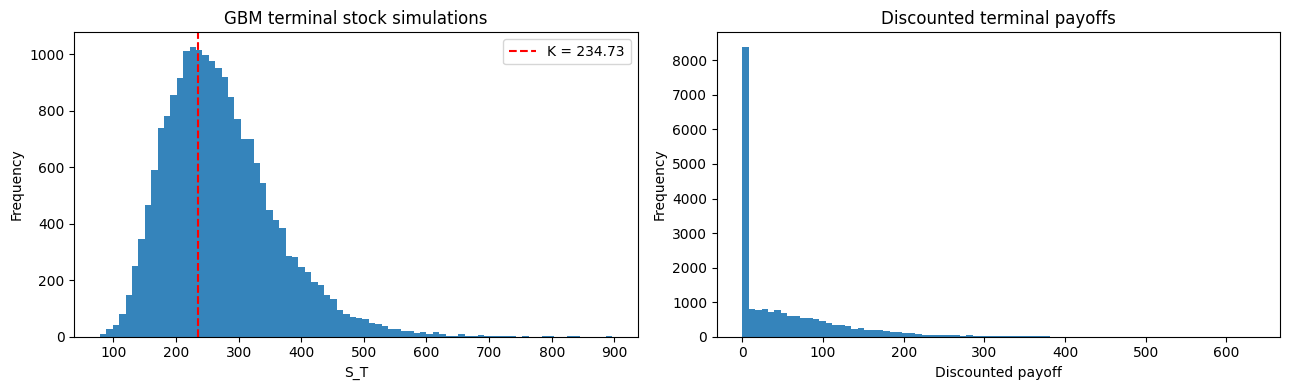

In [17]:
# Monte Carlo pricing under GBM

q = 0.0  # dividend yield
n_sims = 20_000
Z = np.random.normal(size=n_sims)

S_T_gbm = S * np.exp((r - q - 0.5 * sigma_annual**2) * T + sigma_annual * np.sqrt(T) * Z)
payoff_call_gbm = np.maximum(S_T_gbm - K, 0.0)
mc_call_gbm = np.exp(-r * T) * payoff_call_gbm.mean()
mc_call_gbm_se = np.exp(-r * T) * payoff_call_gbm.std(ddof=1) / np.sqrt(n_sims)

import matplotlib.pyplot as plt

# plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(S_T_gbm, bins=80, alpha=0.9)
axes[0].axvline(K, color="red", linestyle="--", label=f"K = {K:.2f}")
axes[0].set_title("GBM terminal stock simulations")
axes[0].set_xlabel("S_T")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(np.exp(-r * T) * payoff_call_gbm, bins=80, alpha=0.9)
axes[1].set_title("Discounted terminal payoffs")
axes[1].set_xlabel("Discounted payoff")
axes[1].set_ylabel("Frequency")

plt.tight_layout()

print("Q6b — Monte Carlo Call Price (GBM")
print("=" * 70)
print(f"Simulations: {n_sims:,}")
print(f"MC call price: ${mc_call_gbm:.4f}")
print(f"Std. error:    ${mc_call_gbm_se:.4f}")
print(f"BS call (Q3b): ${call_price:.4f}  (benchmark)")


## (c) — Local Volatility via Finite Differences (Dupire Approximation)

We estimate the **local volatility** at the point $(K,T)$ by approximating derivatives of the call price with **finite differences**.

### Finite-Difference Grid
Evaluate nearby prices:
- $C(K+\Delta K, T)$, $C(K-\Delta K, T)$
- $C(K, T+\Delta T)$, $C(K, T-\Delta T)$

Bump sizes:
$$
\Delta K = 0.01K, \qquad 
\Delta T = \min\!\left(\frac{1}{12}, \frac{T}{2}\right)
$$

### Derivative Approximations
$$
\frac{\partial C}{\partial T} \approx 
\frac{C(K,T+\Delta T) - C(K,T-\Delta T)}{2\Delta T}
$$

$$
\frac{\partial C}{\partial K} \approx 
\frac{C(K+\Delta K,T) - C(K-\Delta K,T)}{2\Delta K}
$$

$$
\frac{\partial^2 C}{\partial K^2} \approx 
\frac{C(K+\Delta K,T) - 2C(K,T) + C(K-\Delta K,T)}{\Delta K^2}
$$

### Dupire Local Volatility
Let $\mu_{rn} = r - q$. The local variance is

$$
\sigma_{\text{loc}}^2(K,T)
=
\frac{
\frac{\partial C}{\partial T} + (r-q)K\frac{\partial C}{\partial K} + qC
}{
\tfrac{1}{2}K^2 \frac{\partial^2 C}{\partial K^2}
}
$$

If the estimate becomes non-positive due to numerical noise, it is **floored to a small positive value** before computing $\sigma_{\text{loc}}$.

In [18]:
# Local volatility via finite differences (Dupire-style)
dK = 0.01 * K
dT = min(1.0/12.0, 0.5*T)  # keep T-dT positive

def C(K_, T_):
    return bs_call_price(S, K_, T_, r, sigma_annual)

C_Kp = C(K + dK, T)
C_Km = C(K - dK, T)
C_Tp = C(K, T + dT)
C_Tm = C(K, T - dT)

# Finite-difference partial derivatives:
dC_dT = (C_Tp - C_Tm) / (2.0 * dT)
dC_dK = (C_Kp - C_Km) / (2.0 * dK)
d2C_dK2 = (C_Kp - 2.0 * call_price + C_Km) / (dK**2)

# Under risk-neutral pricing, drift is (r-q).
mu_rn = (r - q)

# Dupire local volatility (one common form, with q=0):
#   σ_loc^2(K,T) = [∂C/∂T + (r-q)K ∂C/∂K + q C] / [0.5 K^2 ∂²C/∂K²]
numerator = dC_dT + mu_rn * K * dC_dK + q * call_price
denominator = 0.5 * (K**2) * d2C_dK2
sigma_loc_sq = numerator / denominator

# Numerical guard: sigma_loc_sq should be positive; if not, we clip it
sigma_loc = np.sqrt(max(sigma_loc_sq, 1e-12))

print("Q6c — Local Volatility at (K,T) from finite differences")
print("=" * 80)
print(f"ΔK = {dK:.4f}, ΔT = {dT:.6f} years")
print(f"∂C/∂T   ≈ {dC_dT:.6f}")
print(f"∂C/∂K   ≈ {dC_dK:.6f}")
print(f"∂²C/∂K² ≈ {d2C_dK2:.8f}")
print("-" * 80)
print(f"sigma_loc^2(K,T) ≈ {sigma_loc_sq:.6f}")
print(f"sigma_loc(K,T)   ≈ {sigma_loc:.6f}  ({sigma_loc*100:.2f}%)")


Q6c — Local Volatility at (K,T) from finite differences
ΔK = 2.3473, ΔT = 0.083333 years
∂C/∂T   ≈ 19.467907
∂C/∂K   ≈ -0.595795
∂²C/∂K² ≈ 0.00485672
--------------------------------------------------------------------------------
sigma_loc^2(K,T) ≈ 0.102750
sigma_loc(K,T)   ≈ 0.320546  (32.05%)


# (d) — Monte Carlo Call Pricing under (Simplified) Local Volatility

We simulate the asset price dynamics under the process

$$
dS_t = (r - q) S_t \, dt + \sigma_{loc} S_t \, dW_t
$$

using the **exact GBM-style terminal solution**, but replacing the volatility parameter with  $\sigma = \sigma_{loc}$.

In a full **local volatility model**, the volatility is a function of both the asset price and time:

$$
\sigma_{loc} = \sigma_{loc}(S_t, t)
$$

However, for this exercise we simplify the framework by keeping the local volatility **constant**, using the level estimated in **Q6c**.

In [19]:
Z2 = np.random.normal(size=n_sims)
S_T_lv = S * np.exp((r - q - 0.5 * sigma_loc**2) * T + sigma_loc * np.sqrt(T) * Z2)
payoff_call_lv = np.maximum(S_T_lv - K, 0.0)
mc_call_lv = np.exp(-r * T) * payoff_call_lv.mean()
mc_call_lv_se = np.exp(-r * T) * payoff_call_lv.std(ddof=1) / np.sqrt(n_sims)

print("Q6d — Monte Carlo Call Price (Local Vol, simplified)")
print("=" * 80)
print(f"Simulations: {n_sims:,}")
print(f"Local vol used: {sigma_loc:.4f} ({sigma_loc*100:.2f}%)")
print(f"MC call price:  ${mc_call_lv:.4f}")
print(f"Std. error:     ${mc_call_lv_se:.4f}")
print(f"MC (GBM):       ${mc_call_gbm:.4f}  (from Q6b)")


Q6d — Monte Carlo Call Price (Local Vol, simplified)
Simulations: 20,000
Local vol used: 0.3205 (32.05%)
MC call price:  $53.0257
Std. error:     $0.5042
MC (GBM):       $52.2153  (from Q6b)


# Q7 — Hedging Concepts
**Hedging** is the act of taking positions designed to **reduce** (not eliminate) exposure to a risk factor.

### What is hedging?
Given a portfolio value $\pi$ that depends on market variables (e.g., $S$, $\sigma$, $r$), **hedging** aims to make $\pi$ less sensitive to these variables. This is typically achieved by adding financial instruments whose **Greeks** offset those of the portfolio.

### Why hedge?
- Risk management: stabilize P&L, control downside, meet risk limits.
- Business necessity: many firms must hedge inputs/outputs (FX, commodities, rates).
- Capital efficiency: reduce tail risk and regulatory capital usage.

### Who hedges?
- Market makers and option desks (dynamic hedging of Greeks).
- Corporates (FX/rates/commodity exposures).
- Asset managers / hedge funds (risk budgeting, factor hedging).

### Main approaches
1) **Static hedging**: hold a hedge to maturity (rare for options).
2) **Dynamic hedging**: rebalance through time (e.g., delta hedging).
3) **Greek hedging**: target specific sensitivities (delta-, gamma-, vega-neutral, etc.).
4) **Scenario / stress hedging**: hedge against large moves rather than infinitesimal changes.


# Q8 — Delta Hedging

## Check outputs (not finished)

In [20]:
# Helper: BS Greeks
def bs_delta_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    return N(d1)

def bs_gamma(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def bs_vega(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

In [21]:
# Delta-neutral portfolio (Covered Call)
# Strategy: Long 25,000 shares + Short N call options
# Portfolio delta = 25000 * 1 + N_options * (-delta_call) = 0

n_shares = 25000
delta_call = bs_delta_call(S, K, T, r, sigma_annual)
gamma_call = bs_gamma(S, K, T, r, sigma_annual)

# Number of calls to short for delta-neutral
n_options = n_shares / delta_call

In [22]:
print("Q8a -- Delta-Neutral Portfolio (Covered Call)")
print("=" * 55)
print(f"  Position:          Long {n_shares:,} shares of {ticker}")
print(f"  Strategy:          Covered Call (short calls)")
print(f"  Call delta:        {delta_call:.6f}")
print(f"  Call gamma:        {gamma_call:.6f}")
print(f"  Options to short:  {n_options:.2f} calls")
print(f"  Rounded:           {round(n_options)} calls")
print(f"\n  Verification:")
print(f"  Portfolio delta = {n_shares} * 1 + {round(n_options)} * (-{delta_call:.4f})")
portfolio_delta = n_shares - round(n_options) * delta_call
print(f"  Portfolio delta = {portfolio_delta:.4f}")
if abs(portfolio_delta) < 1:
    print(f"  ≈ 0 (residual due to rounding of {n_options:.2f} -> {round(n_options)})")
else:
    print(f"  Non-negligible residual -> consider adjusting option count")
print(f"\n  Interpretation:")
print(f"  We need to short {round(n_options)} call options to offset the delta of our {n_shares:,} share long position.")
print(f"  Since each call has delta {delta_call:.4f} < 1, we need more options than shares to achieve neutrality.")

Q8a -- Delta-Neutral Portfolio (Covered Call)
  Position:          Long 25,000 shares of AAPL
  Strategy:          Covered Call (short calls)
  Call delta:        0.734880
  Call gamma:        0.003907
  Options to short:  34019.14 calls
  Rounded:           34019 calls

  Verification:
  Portfolio delta = 25000 * 1 + 34019 * (-0.7349)
  Portfolio delta = 0.1053
  ≈ 0 (residual due to rounding of 34019.14 -> 34019)

  Interpretation:
  We need to short 34019 call options to offset the delta of our 25,000 share long position.
  Since each call has delta 0.7349 < 1, we need more options than shares to achieve neutrality.


In [23]:
# Q8b -- Effect of +$1.5 price increase
dS = 1.5
S_new = S + dS

# New call price and delta after the move
call_price_new = BS_CALL(S_new, K, T, r, sigma_annual)
delta_call_new = bs_delta_call(S_new, K, T, r, sigma_annual)

# P&L of each leg
pnl_shares = n_shares * dS
pnl_options = -round(n_options) * (call_price_new - call_price)
pnl_total = pnl_shares + pnl_options

In [24]:
print("Q8b -- Effect of +$1.5 Price Increase")
print("=" * 55)
print(f"  New stock price:   ${S_new:.2f} (was ${S:.2f})")
print(f"  New call price:    ${call_price_new:.2f} (was ${call_price:.2f})")
print(f"\n  P&L breakdown:")
print(f"  Shares:   {n_shares:,} × ${dS} = +${pnl_shares:,.2f}")
print(f"  Options:  -{round(n_options)} × (${call_price_new:.2f} - ${call_price:.2f}) = ${pnl_options:,.2f}")
print(f"  Total P&L: ${pnl_total:,.2f}")
print(f"\n  Interpretation:")
print(f"  The portfolio is approximately delta-neutral, so the gains on shares are mostly offset by losses on short calls.")
print(f"  The small residual P&L (${pnl_total:,.2f}) comes from the gamma effect (convexity).")

Q8b -- Effect of +$1.5 Price Increase
  New stock price:   $263.23 (was $261.73)
  New call price:    $53.59 (was $52.49)

  P&L breakdown:
  Shares:   25,000 × $1.5 = +$37,500.00
  Options:  -34019 × ($53.59 - $52.49) = $-37,648.51
  Total P&L: $-148.51

  Interpretation:
  The portfolio is approximately delta-neutral, so the gains on shares are mostly offset by losses on short calls.
  The small residual P&L ($-148.51) comes from the gamma effect (convexity).


In [25]:
# Delta after move + rebalancing
portfolio_delta_new = n_shares - round(n_options) * delta_call_new

# Rebalancing: adjust number of options
n_options_new = n_shares / delta_call_new
adjustment = n_options_new - round(n_options)

In [26]:
print("Q8c -- Delta After Move & Rebalancing")
print("=" * 55)
print(f"  Old call delta:      {delta_call:.6f}")
print(f"  New call delta:      {delta_call_new:.6f}")
print(f"  Delta change:        {delta_call_new - delta_call:.6f}")
print(f"\n  Portfolio delta after move:")
print(f"  = {n_shares} - {round(n_options)} × {delta_call_new:.4f}")
print(f"  = {portfolio_delta_new:.4f}")
print(f"\n  The portfolio is no longer delta-neutral.")
print(f"\n  Rebalancing:")
print(f"  New options needed:  {n_options_new:.2f}")
print(f"  Currently short:     {round(n_options)}")
print(f"  Adjustment:          short {adjustment:.2f} additional calls")
print(f"\n  Interpretation:")
print(f"  After the $1.5 increase, delta rose (call is more ITM), so our short call position no longer fully offsets the share delta")
print(f"  We must short ~{abs(round(adjustment))} more calls to restore delta neutrality.")


Q8c -- Delta After Move & Rebalancing
  Old call delta:      0.734880
  New call delta:      0.740691
  Delta change:        0.005810

  Portfolio delta after move:
  = 25000 - 34019 × 0.7407
  = -197.5621

  The portfolio is no longer delta-neutral.

  Rebalancing:
  New options needed:  33752.27
  Currently short:     34019
  Adjustment:          short -266.73 additional calls

  Interpretation:
  After the $1.5 increase, delta rose (call is more ITM), so our short call position no longer fully offsets the share delta
  We must short ~267 more calls to restore delta neutrality.


# Q9 — Gamma Hedging

**Delta hedging** removes the *first-order* sensitivity of a portfolio to the underlying price $S$. However, when $S$ moves, the **Delta itself changes**.

**Gamma hedging** addresses this by neutralizing the portfolio’s curvature with respect to $S$:

$$
\Gamma_{\text{portfolio}} = \sum_i n_i \Gamma_i
$$

The goal is to construct a **delta–gamma neutral** portfolio using:

- the **underlying stock** ($\Delta = 1,\ \Gamma = 0$),
- the **call option from Q3b** (Option 1),
- a second **additional option** (Option 2).

## Data Source Note

In practice, **Option 2** would be selected from a live **option chain** (e.g., market data providers or exchange feeds).  
For this exercise, we instead **specify Option 2 parameters directly** and compute its Greeks using the **Black–Scholes model**.

In [27]:
# Build a delta-gamma neutral position

# Portfolio setup (same as Q8a): long 25,000 shares
n_shares = 25_000

# Option 1: the Q3b call (same K, T)
K1, T1 = K, T
delta1 = delta_call
gamma1 = gamma_call

# Option 2: a "random" call (example choice)
# Logical choice: different strike and maturity to ensure a different gamma.
K2 = 1.10 * K          # 10% higher strike
T2 = 0.50 * T          # 6 months if T=1 year
sigma2 = sigma_annual  # use same vol estimate for a self-contained notebook
d1_2, d2_2 = bs_d1_d2(S, K2, T2, r, sigma2)
delta2 = N(d1_2)
gamma2 = norm.pdf(d1_2) / (S * sigma2 * np.sqrt(T2))

# We solve for n1 and n2 (number of options) such that:
#   Delta_total = n_shares*1 + n1*delta1 + n2*delta2 = 0
#   Gamma_total =            n1*gamma1 + n2*gamma2 = 0
#
# positive n means LONG the option. Negative means SHORT.

A = np.array([[delta1, delta2],
              [gamma1, gamma2]], dtype=float)
b = np.array([-n_shares, 0.0], dtype=float)

n1, n2 = np.linalg.solve(A, b)

delta_total = n_shares + n1*delta1 + n2*delta2
gamma_total = n1*gamma1 + n2*gamma2

print("Q9a — Delta-Gamma Neutral Construction")
print("=" * 85)
print("Option 1 (Q3b call):")
print(f"  K1={K1:.2f}, T1={T1:.2f}y, sigma={sigma_annual:.4f}, delta1={delta1:.6f}, gamma1={gamma1:.8f}")
print("Option 2 (example 'random' call):")
print(f"  K2={K2:.2f}, T2={T2:.2f}y, sigma={sigma2:.4f}, delta2={delta2:.6f}, gamma2={gamma2:.8f}")
print("-" * 85)
print("Holdings that make the portfolio locally delta- and gamma-neutral:")
print(f"  Shares:  +{n_shares:,}")
print(f"  Option 1: {n1:,.2f} contracts")
print(f"  Option 2: {n2:,.2f} contracts")
print("-" * 85)
print(f"Check: Delta_total ≈ {delta_total:.6f}")
print(f"Check: Gamma_total ≈ {gamma_total:.10f}")


Q9a — Delta-Gamma Neutral Construction
Option 1 (Q3b call):
  K1=234.73, T1=1.00y, sigma=0.3204, delta1=0.734880, gamma1=0.00390675
Option 2 (example 'random' call):
  K2=258.21, T2=0.50y, sigma=0.3204, delta2=0.603876, gamma2=0.00649841
-------------------------------------------------------------------------------------
Holdings that make the portfolio locally delta- and gamma-neutral:
  Shares:  +25,000
  Option 1: -67,233.39 contracts
  Option 2: 40,419.72 contracts
-------------------------------------------------------------------------------------
Check: Delta_total ≈ 0.000000
Check: Gamma_total ≈ 0.0000000000


In [28]:
# Can we maintain a delta-gamma neutral position after S moves?

# After a move in S, deltas and gammas change, so a previously neutral portfolio is no longer neutral.
# We illustrate this with a +$1.5 move (same shock used in Q8b).

dS = 1.5
S_new = S + dS

# Recompute greeks at the new spot for both options
d1_1_new, d2_1_new = bs_d1_d2(S_new, K1, T1, r, sigma_annual)
delta1_new = N(d1_1_new)
gamma1_new = norm.pdf(d1_1_new) / (S_new * sigma_annual * np.sqrt(T1))

d1_2_new, d2_2_new = bs_d1_d2(S_new, K2, T2, r, sigma2)
delta2_new = N(d1_2_new)
gamma2_new = norm.pdf(d1_2_new) / (S_new * sigma2 * np.sqrt(T2))

delta_total_new = n_shares + n1*delta1_new + n2*delta2_new
gamma_total_new = n1*gamma1_new + n2*gamma2_new

print("Q9b — After a +$1.5 move, neutrality breaks (because Greeks change).")
print("=" * 90)
print(f"New spot: S' = {S_new:.2f} (was {S:.2f})")
print("-" * 90)
print(f"Old deltas:  delta1={delta1:.6f}, delta2={delta2:.6f}")
print(f"New deltas:  delta1'={delta1_new:.6f}, delta2'={delta2_new:.6f}")
print(f"Old gammas:  gamma1={gamma1:.8f}, gamma2={gamma2:.8f}")
print(f"New gammas:  gamma1'={gamma1_new:.8f}, gamma2'={gamma2_new:.8f}")
print("-" * 90)
print(f"Portfolio after move: Delta ≈ {delta_total_new:.2f}, Gamma ≈ {gamma_total_new:.6f}")

# Rebalancing: solve again at S_new for new (n1', n2') that restores neutrality
A_new = np.array([[delta1_new, delta2_new],
                  [gamma1_new, gamma2_new]], dtype=float)
b_new = np.array([-n_shares, 0.0], dtype=float)

n1_reb, n2_reb = np.linalg.solve(A_new, b_new)

print("-" * 90)
print("One way to maintain delta-gamma neutrality is to rebalance the option quantities:")
print(f"  New Option 1 holding: {n1_reb:,.2f}  (change = {n1_reb - n1:,.2f})")
print(f"  New Option 2 holding: {n2_reb:,.2f}  (change = {n2_reb - n2:,.2f})")


Q9b — After a +$1.5 move, neutrality breaks (because Greeks change).
New spot: S' = 263.23 (was 261.73)
------------------------------------------------------------------------------------------
Old deltas:  delta1=0.734880, delta2=0.603876
New deltas:  delta1'=0.740691, delta2'=0.613563
Old gammas:  gamma1=0.00390675, gamma2=0.00649841
New gammas:  gamma1'=0.00384063, gamma2'=0.00641655
------------------------------------------------------------------------------------------
Portfolio after move: Delta ≈ 0.87, Gamma ≈ 1.136522
------------------------------------------------------------------------------------------
One way to maintain delta-gamma neutrality is to rebalance the option quantities:
  New Option 1 holding: -66,944.70  (change = 288.69)
  New Option 2 holding: 40,069.80  (change = -349.92)


# Q10 — Vega Hedging

In [29]:
# Call spread: Long call at K1 = K, Short call at K2 = 1.3 * K
K1 = K
K2 = 1.3 * K

# Prices
call_price_K1 = BS_CALL(S, K1, T, r, sigma_annual)  # same as call_price
call_price_K2 = BS_CALL(S, K2, T, r, sigma_annual)

# Vegas
vega_K1 = bs_vega(S, K1, T, r, sigma_annual)
vega_K2 = bs_vega(S, K2, T, r, sigma_annual)

# Net vega of the spread (long K1, short K2)
net_vega = vega_K1 - vega_K2

# Deltas for reference
delta_K1 = bs_delta_call(S, K1, T, r, sigma_annual)
delta_K2 = bs_delta_call(S, K2, T, r, sigma_annual)
net_delta = delta_K1 - delta_K2

In [30]:
print("Q10 -- Vega Hedging (Call Spread)")
print("=" * 55)
print(f"  Long call:   K1 = ${K1:.2f} (mean price)")
print(f"  Short call:  K2 = ${K2:.2f} (K1 × 1.3)")
print(f"\n  Prices:")
print(f"  Call K1:  ${call_price_K1:.2f}")
print(f"  Call K2:  ${call_price_K2:.2f}")
print(f"  Spread cost: ${call_price_K1 - call_price_K2:.2f}")
print(f"\n  Vegas:")
print(f"  Vega K1:    {vega_K1:.4f}")
print(f"  Vega K2:    {vega_K2:.4f}")
print(f"  Net vega:   {net_vega:.4f}")
print(f"\n  Deltas:")
print(f"  Delta K1:   {delta_K1:.4f}")
print(f"  Delta K2:   {delta_K2:.4f}")
print(f"  Net delta:  {net_delta:.4f}")


Q10 -- Vega Hedging (Call Spread)
  Long call:   K1 = $234.73 (mean price)
  Short call:  K2 = $305.15 (K1 × 1.3)

  Prices:
  Call K1:  $52.49
  Call K2:  $21.84
  Spread cost: $30.65

  Vegas:
  Vega K1:    85.7476
  Vega K2:    102.5237
  Net vega:   -16.7761

  Deltas:
  Delta K1:   0.7349
  Delta K2:   0.4242
  Net delta:  0.3107


In [31]:
# Vega-neutral adjustment
# To neutralize vega, we need an additional option position
# Using a new ATM call (K3 = S) as the hedging instrument
K3 = S
vega_K3 = bs_vega(S, K3, T, r, sigma_annual)
delta_K3 = bs_delta_call(S, K3, T, r, sigma_annual)

# Number of K3 options: net_vega + n_hedge * vega_K3 = 0
# If net_vega > 0, we are long vega → short K3 calls
n_hedge = -net_vega / vega_K3

In [32]:
print(f"  Hedging instrument: ATM call (K3 = ${K3:.2f})")
print(f"  Vega K3:  {vega_K3:.4f}")
print(f"  Delta K3: {delta_K3:.4f}")
print(f"\n  Vega-neutral adjustment:")
print(f"  n = -net_vega / vega_K3")
print(f"  n = -{net_vega:.4f} / {vega_K3:.4f}")
print(f"  n = {n_hedge:.4f}")

if n_hedge < 0:
    print(f"\n  Action: Short {abs(n_hedge):.2f} ATM calls to neutralize vega")
else:
    print(f"\n  Action: Buy {n_hedge:.2f} ATM calls to neutralize vega")

  Hedging instrument: ATM call (K3 = $261.73)
  Vega K3:  100.1777
  Delta K3: 0.6133

  Vega-neutral adjustment:
  n = -net_vega / vega_K3
  n = --16.7761 / 100.1777
  n = 0.1675

  Action: Buy 0.17 ATM calls to neutralize vega


In [33]:
# Final portfolio vega & delta
final_vega = net_vega + n_hedge * vega_K3
final_delta = net_delta + n_hedge * delta_K3

print(f"  Final portfolio:")
print(f"  Vega = {net_vega:.4f} + {n_hedge:.4f} × {vega_K3:.4f} = {final_vega:.6f} ≈ 0 ✓")
print(f"  Delta = {net_delta:.4f} + {n_hedge:.4f} × {delta_K3:.4f} = {final_delta:.4f}")
print(f"\n  Interpretation:")
print(f"  The call spread has positive net vega ({net_vega:.4f}), meaning the portfolio gains value when volatility rises.")
print(f"  To achieve vega neutrality, we {'short' if n_hedge < 0 else 'buy'} {abs(n_hedge):.2f} ATM calls, eliminating sensitivity to volatility changes.")
print(f"  Note: this adjustment changes delta to {final_delta:.4f}, which may require further delta hedging if needed.")

  Final portfolio:
  Vega = -16.7761 + 0.1675 × 100.1777 = 0.000000 ≈ 0 ✓
  Delta = 0.3107 + 0.1675 × 0.6133 = 0.4134

  Interpretation:
  The call spread has positive net vega (-16.7761), meaning the portfolio gains value when volatility rises.
  To achieve vega neutrality, we buy 0.17 ATM calls, eliminating sensitivity to volatility changes.
  Note: this adjustment changes delta to 0.4134, which may require further delta hedging if needed.
